In [17]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

print("Setup complete!")

Setup complete!


In [18]:
def forward_pass(X, W1, b1, W2, b2, W3, b3):
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)
    return Z1, A1, Z2, A2, Z3, A3

print("Forward pass function defined!")

Forward pass function defined!


In [19]:
def mse_loss(Y_true, Y_pred):
    m = Y_true.shape[0]
    loss = (1/m) * np.sum((Y_true - Y_pred) ** 2)
    return loss

print("Loss function defined!")

Loss function defined!


In [20]:
def backpropagation(X, Y_true, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3):
    m = X.shape[0]

    delta3 = -2 * (Y_true - A3) * sigmoid_derivative(A3)
    dW3 = (1/m) * (A2.T @ delta3)
    db3 = (1/m) * np.sum(delta3, axis=0, keepdims=True)

    delta2 = (delta3 @ W3.T) * sigmoid_derivative(A2)
    dW2 = (1/m) * (A1.T @ delta2)
    db2 = (1/m) * np.sum(delta2, axis=0, keepdims=True)

    delta1 = (delta2 @ W2.T) * sigmoid_derivative(A1)
    dW1 = (1/m) * (X.T @ delta1)
    db1 = (1/m) * np.sum(delta1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3

print("Backpropagation function defined!")

Backpropagation function defined!


In [21]:
def update_weights(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, lr):
    W1_new = W1 - lr * dW1
    b1_new = b1 - lr * db1
    W2_new = W2 - lr * dW2
    b2_new = b2 - lr * db2
    W3_new = W3 - lr * dW3
    b3_new = b3 - lr * db3
    return W1_new, b1_new, W2_new, b2_new, W3_new, b3_new

print("Update function defined!")

Update function defined!


In [22]:
# Dataset
X_train = np.array([[0.2, 0.8],
                    [0.9, 0.4],
                    [0.1, 0.2]])
Y_train = np.array([[1], [1], [0]])

# Your weights from Excel
W1 = np.array([[-0.52, -0.63],
               [0.39, 0.56]])
b1 = np.array([[0.01, 0.01]])

W2 = np.array([[-0.32, 0.63],
               [0.50, -0.21]])
b2 = np.array([[-0.11, -0.11]])

W3 = np.array([[0.15],
               [-0.23]])
b3 = np.array([[0.0]])

print("=" * 50)
print("Roll No: 25I-2633")
print("Weights loaded!")
print(f"w1={W1[0,0]}, w2={W1[0,1]}, w3={W1[1,0]}, w4={W1[1,1]}")
print(f"w5={W2[0,0]}, w6={W2[0,1]}, w7={W2[1,0]}, w8={W2[1,1]}")
print(f"w9={W3[0,0]}, w10={W3[1,0]}")
print(f"b1={b1[0,0]}, b2={b2[0,0]}")
print("=" * 50)

Roll No: 25I-2633
Weights loaded!
w1=-0.52, w2=-0.63, w3=0.39, w4=0.56
w5=-0.32, w6=0.63, w7=0.5, w8=-0.21
w9=0.15, w10=-0.23
b1=0.01, b2=-0.11


In [23]:
print("\n" + "=" * 50)
print("TASK 1B: Forward Pass for Sample s(1)")
print("=" * 50)

Z1, A1, Z2, A2, Z3, A3 = forward_pass(X_train[0:1], W1, b1, W2, b2, W3, b3)

print(f"Input: x1=0.2, x2=0.8")
print(f"\nHidden Layer 1:")
print(f"  z1 = {Z1[0,0]:.4f}")
print(f"  a1 = σ(z1) = {A1[0,0]:.4f}")
print(f"  z2 = {Z1[0,1]:.4f}")
print(f"  a2 = σ(z2) = {A1[0,1]:.4f}")

print(f"\nHidden Layer 2:")
print(f"  z3 = {Z2[0,0]:.4f}")
print(f"  a3 = σ(z3) = {A2[0,0]:.4f}")
print(f"  z4 = {Z2[0,1]:.4f}")
print(f"  a4 = σ(z4) = {A2[0,1]:.4f}")

print(f"\nOutput Layer:")
print(f"  z_output = {Z3[0,0]:.4f}")
print(f"  ŷ = σ(z_output) = {A3[0,0]:.4f}")
print(f"  True label y = 1")
print(f"  Error = {1 - A3[0,0]:.4f}")


TASK 1B: Forward Pass for Sample s(1)
Input: x1=0.2, x2=0.8

Hidden Layer 1:
  z1 = 0.2180
  a1 = σ(z1) = 0.5543
  z2 = 0.3320
  a2 = σ(z2) = 0.5822

Hidden Layer 2:
  z3 = 0.0038
  a3 = σ(z3) = 0.5009
  z4 = 0.1169
  a4 = σ(z4) = 0.5292

Output Layer:
  z_output = -0.0466
  ŷ = σ(z_output) = 0.4884
  True label y = 1
  Error = 0.5116


In [24]:
print("\n" + "=" * 50)
print("TASK 1C: Forward Pass for All Samples")
print("=" * 50)

print("\n| Sample | x1 | x2 | a1 | a2 | a3 | a4 | y | ŷ |")
print("|--------|----|----|----|----|----|----|----|-----|")

for i in range(3):
    _, A1, _, A2, _, A3 = forward_pass(X_train[i:i+1], W1, b1, W2, b2, W3, b3)
    print(f"| s({i+1}) | {X_train[i,0]:.1f} | {X_train[i,1]:.1f} | "
          f"{A1[0,0]:.4f} | {A1[0,1]:.4f} | "
          f"{A2[0,0]:.4f} | {A2[0,1]:.4f} | "
          f"{Y_train[i,0]:d} | {A3[0,0]:.4f} |")


TASK 1C: Forward Pass for All Samples

| Sample | x1 | x2 | a1 | a2 | a3 | a4 | y | ŷ |
|--------|----|----|----|----|----|----|----|-----|
| s(1) | 0.2 | 0.8 | 0.5543 | 0.5822 | 0.5009 | 0.5292 | 1 | 0.4884 |
| s(2) | 0.9 | 0.4 | 0.4251 | 0.4175 | 0.4907 | 0.5175 | 1 | 0.4886 |
| s(3) | 0.1 | 0.2 | 0.5090 | 0.5147 | 0.4961 | 0.5256 | 0 | 0.4884 |


In [25]:
print("\n" + "=" * 50)
print("TASK 2: MSE Loss Calculation")
print("=" * 50)

_, _, _, _, _, predictions = forward_pass(X_train, W1, b1, W2, b2, W3, b3)

print("\nIndividual squared errors:")
total = 0
for i in range(3):
    error = (Y_train[i,0] - predictions[i,0])**2
    total += error
    print(f"  Sample {i+1}: ({Y_train[i,0]} - {predictions[i,0]:.4f})² = {error:.4f}")

loss = total / 3
print(f"\nMSE Loss = (1/3) × {total:.4f} = {loss:.4f}")


TASK 2: MSE Loss Calculation

Individual squared errors:
  Sample 1: (1 - 0.4884)² = 0.2618
  Sample 2: (1 - 0.4886)² = 0.2615
  Sample 3: (0 - 0.4884)² = 0.2385

MSE Loss = (1/3) × 0.7618 = 0.2539


In [26]:
print("\n" + "=" * 50)
print("TASK 3: Backpropagation for Sample s(1)")
print("=" * 50)

# Forward pass for s(1)
Z1, A1, Z2, A2, Z3, A3 = forward_pass(X_train[0:1], W1, b1, W2, b2, W3, b3)

# Backpropagation
dW1, db1, dW2, db2, dW3, db3 = backpropagation(
    X_train[0:1], Y_train[0:1], Z1, A1, Z2, A2, Z3, A3, W1, W2, W3
)

print(f"\nOutput Layer:")
print(f"  δ₃ = {(-2*(1-A3[0,0])*A3[0,0]*(1-A3[0,0])):.6f}")
print(f"  ∂L/∂w9 = {dW3[0,0]:.6f}")
print(f"  ∂L/∂w10 = {dW3[1,0]:.6f}")

print(f"\nHidden Layer 2:")
print(f"  δ₁⁽²⁾ = {dW2[0,0]/A1[0,0] if A1[0,0]!=0 else 0:.6f}")
print(f"  δ₂⁽²⁾ = {dW2[0,1]/A1[0,0] if A1[0,0]!=0 else 0:.6f}")
print(f"  ∂L/∂w5 = {dW2[0,0]:.6f}")
print(f"  ∂L/∂w6 = {dW2[0,1]:.6f}")
print(f"  ∂L/∂w7 = {dW2[1,0]:.6f}")
print(f"  ∂L/∂w8 = {dW2[1,1]:.6f}")
print(f"  ∂L/∂b2 = {db2[0,0]:.6f}")

print(f"\nHidden Layer 1:")
print(f"  ∂L/∂w1 = {dW1[0,0]:.6f}")
print(f"  ∂L/∂w2 = {dW1[0,1]:.6f}")
print(f"  ∂L/∂w3 = {dW1[1,0]:.6f}")
print(f"  ∂L/∂w4 = {dW1[1,1]:.6f}")
print(f"  ∂L/∂b1 = {db1[0,0]:.6f}")


TASK 3: Backpropagation for Sample s(1)

Output Layer:
  δ₃ = -0.255682
  ∂L/∂w9 = -0.128081
  ∂L/∂w10 = -0.135307

Hidden Layer 2:
  δ₁⁽²⁾ = -0.009588
  δ₂⁽²⁾ = 0.014652
  ∂L/∂w5 = -0.005315
  ∂L/∂w6 = 0.008121
  ∂L/∂w7 = -0.005583
  ∂L/∂w8 = 0.008531
  ∂L/∂b2 = -0.009588

Hidden Layer 1:
  ∂L/∂w1 = 0.000608
  ∂L/∂w2 = -0.000383
  ∂L/∂w3 = 0.002431
  ∂L/∂w4 = -0.001532
  ∂L/∂b1 = 0.003038


In [27]:
print("\n" + "=" * 50)
print("TASK 4: Weight Update (η = 0.1)")
print("=" * 50)

lr = 0.1

W1_new, b1_new, W2_new, b2_new, W3_new, b3_new = update_weights(
    W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, lr
)

print("\nUpdated weights:")
print(f"  w1: {W1[0,0]:.4f} → {W1_new[0,0]:.6f}")
print(f"  w2: {W1[0,1]:.4f} → {W1_new[0,1]:.6f}")
print(f"  w3: {W1[1,0]:.4f} → {W1_new[1,0]:.6f}")
print(f"  w4: {W1[1,1]:.4f} → {W1_new[1,1]:.6f}")
print(f"  w5: {W2[0,0]:.4f} → {W2_new[0,0]:.6f}")
print(f"  w6: {W2[0,1]:.4f} → {W2_new[0,1]:.6f}")
print(f"  w7: {W2[1,0]:.4f} → {W2_new[1,0]:.6f}")
print(f"  w8: {W2[1,1]:.4f} → {W2_new[1,1]:.6f}")
print(f"  w9: {W3[0,0]:.4f} → {W3_new[0,0]:.6f}")
print(f"  w10: {W3[1,0]:.4f} → {W3_new[1,0]:.6f}")
print(f"  b1: {b1[0,0]:.4f} → {b1_new[0,0]:.6f}")
print(f"  b2: {b2[0,0]:.4f} → {b2_new[0,0]:.6f}")

# Verify loss decreased
_, _, _, _, _, old_pred = forward_pass(X_train, W1, b1, W2, b2, W3, b3)
_, _, _, _, _, new_pred = forward_pass(X_train, W1_new, b1_new, W2_new, b2_new, W3_new, b3_new)

old_loss = mse_loss(Y_train, old_pred)
new_loss = mse_loss(Y_train, new_pred)

print(f"\nLoss before update: {old_loss:.6f}")
print(f"Loss after update:  {new_loss:.6f}")
print(f"Improvement:        {old_loss - new_loss:.6f}")


TASK 4: Weight Update (η = 0.1)

Updated weights:
  w1: -0.5200 → -0.520061
  w2: -0.6300 → -0.629962
  w3: 0.3900 → 0.389757
  w4: 0.5600 → 0.560153
  w5: -0.3200 → -0.319469
  w6: 0.6300 → 0.629188
  w7: 0.5000 → 0.500558
  w8: -0.2100 → -0.210853
  w9: 0.1500 → 0.162808
  w10: -0.2300 → -0.216469
  b1: 0.0100 → 0.009696
  b2: -0.1100 → -0.109041

Loss before update: 0.253926
Loss after update:  0.250534
Improvement:        0.003393



TASK 5: Mini-batch Training (B=2, 20 epochs)
Epoch  1: Loss = 0.250483
Epoch  2: Loss = 0.247355
Epoch  3: Loss = 0.244509
Epoch  4: Loss = 0.244756
Epoch  5: Loss = 0.244994
Epoch  6: Loss = 0.242387
Epoch  7: Loss = 0.242697
Epoch  8: Loss = 0.240305
Epoch  9: Loss = 0.240673
Epoch 10: Loss = 0.241032
Epoch 11: Loss = 0.241380
Epoch 12: Loss = 0.239119
Epoch 13: Loss = 0.237086
Epoch 14: Loss = 0.237530
Epoch 15: Loss = 0.235667
Epoch 16: Loss = 0.233997
Epoch 17: Loss = 0.234496
Epoch 18: Loss = 0.232949
Epoch 19: Loss = 0.231561
Epoch 20: Loss = 0.232084


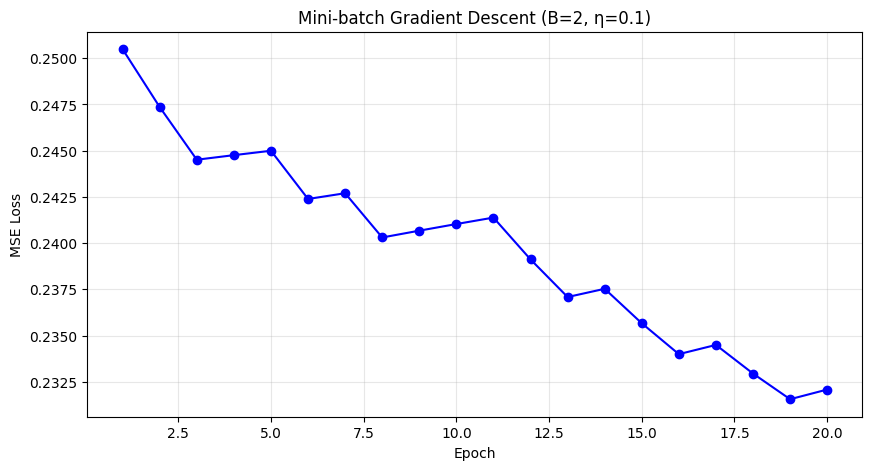

In [28]:
print("\n" + "=" * 50)
print("TASK 5: Mini-batch Training (B=2, 20 epochs)")
print("=" * 50)

# Reset to original weights
W1 = np.array([[-0.52, -0.63], [0.39, 0.56]])
b1 = np.array([[0.01, 0.01]])
W2 = np.array([[-0.32, 0.63], [0.50, -0.21]])
b2 = np.array([[-0.11, -0.11]])
W3 = np.array([[0.15], [-0.23]])
b3 = np.array([[0.0]])

lr = 0.1
batch_size = 2
epochs = 20
loss_history = []

for epoch in range(epochs):
    indices = np.random.permutation(3)
    X_shuffled = X_train[indices]
    Y_shuffled = Y_train[indices]

    for start in range(0, 3, batch_size):
        end = min(start + batch_size, 3)
        X_batch = X_shuffled[start:end]
        Y_batch = Y_shuffled[start:end]

        Z1, A1, Z2, A2, Z3, A3 = forward_pass(X_batch, W1, b1, W2, b2, W3, b3)
        dW1, db1, dW2, db2, dW3, db3 = backpropagation(
            X_batch, Y_batch, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3
        )
        W1, b1, W2, b2, W3, b3 = update_weights(
            W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, lr
        )

    _, _, _, _, _, pred = forward_pass(X_train, W1, b1, W2, b2, W3, b3)
    loss = mse_loss(Y_train, pred)
    loss_history.append(loss)
    print(f"Epoch {epoch+1:2d}: Loss = {loss:.6f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+1), loss_history, 'b-o')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Mini-batch Gradient Descent (B=2, η=0.1)')
plt.grid(True, alpha=0.3)
plt.show()


TASK 6: Momentum Optimizer (β=0.9)
Epoch  1: Loss = 0.253600
Epoch  2: Loss = 0.253276
Epoch  3: Loss = 0.252357
Epoch  4: Loss = 0.251022
Epoch  5: Loss = 0.249956
Epoch  6: Loss = 0.249108
Epoch  7: Loss = 0.248406
Epoch  8: Loss = 0.247309
Epoch  9: Loss = 0.246426
Epoch 10: Loss = 0.245195
Epoch 11: Loss = 0.243721
Epoch 12: Loss = 0.242094
Epoch 13: Loss = 0.240386
Epoch 14: Loss = 0.238657
Epoch 15: Loss = 0.236953
Epoch 16: Loss = 0.235309
Epoch 17: Loss = 0.233770
Epoch 18: Loss = 0.232664
Epoch 19: Loss = 0.231558
Epoch 20: Loss = 0.230482


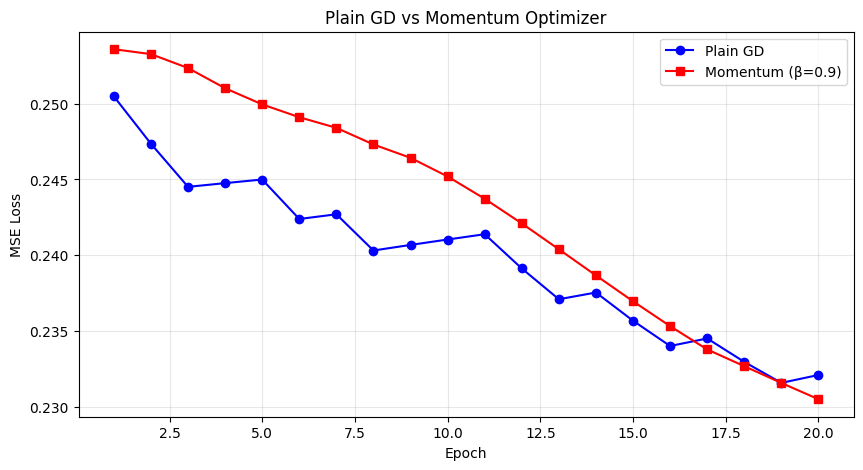

In [29]:
print("\n" + "=" * 50)
print("TASK 6: Momentum Optimizer (β=0.9)")
print("=" * 50)

# Reset weights
W1 = np.array([[-0.52, -0.63], [0.39, 0.56]])
b1 = np.array([[0.01, 0.01]])
W2 = np.array([[-0.32, 0.63], [0.50, -0.21]])
b2 = np.array([[-0.11, -0.11]])
W3 = np.array([[0.15], [-0.23]])
b3 = np.array([[0.0]])

# Initialize velocities
vW1, vb1 = np.zeros_like(W1), np.zeros_like(b1)
vW2, vb2 = np.zeros_like(W2), np.zeros_like(b2)
vW3, vb3 = np.zeros_like(W3), np.zeros_like(b3)

beta = 0.9
lr = 0.1
epochs = 20
loss_history_momentum = []

for epoch in range(epochs):
    indices = np.random.permutation(3)
    X_shuffled = X_train[indices]
    Y_shuffled = Y_train[indices]

    for start in range(0, 3, batch_size):
        end = min(start + batch_size, 3)
        X_batch = X_shuffled[start:end]
        Y_batch = Y_shuffled[start:end]

        Z1, A1, Z2, A2, Z3, A3 = forward_pass(X_batch, W1, b1, W2, b2, W3, b3)
        dW1, db1, dW2, db2, dW3, db3 = backpropagation(
            X_batch, Y_batch, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3
        )

        # Momentum update
        vW1 = beta * vW1 + (1 - beta) * dW1
        vb1 = beta * vb1 + (1 - beta) * db1
        vW2 = beta * vW2 + (1 - beta) * dW2
        vb2 = beta * vb2 + (1 - beta) * db2
        vW3 = beta * vW3 + (1 - beta) * dW3
        vb3 = beta * vb3 + (1 - beta) * db3

        W1 = W1 - lr * vW1
        b1 = b1 - lr * vb1
        W2 = W2 - lr * vW2
        b2 = b2 - lr * vb2
        W3 = W3 - lr * vW3
        b3 = b3 - lr * vb3

    _, _, _, _, _, pred = forward_pass(X_train, W1, b1, W2, b2, W3, b3)
    loss = mse_loss(Y_train, pred)
    loss_history_momentum.append(loss)
    print(f"Epoch {epoch+1:2d}: Loss = {loss:.6f}")

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+1), loss_history, 'b-o', label='Plain GD')
plt.plot(range(1, epochs+1), loss_history_momentum, 'r-s', label='Momentum (β=0.9)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Plain GD vs Momentum Optimizer')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
print("\n" + "=" * 50)
print("FINAL SUMMARY - Roll No: 25I-2633")
print("=" * 50)

# Re-initialize original weights for initial loss calculation
W1_initial = np.array([[-0.52, -0.63], [0.39, 0.56]])
b1_initial = np.array([[0.01, 0.01]])
W2_initial = np.array([[-0.32, 0.63], [0.50, -0.21]])
b2_initial = np.array([[-0.11, -0.11]])
W3_initial = np.array([[0.15], [-0.23]])
b3_initial = np.array([[0.0]])

print(f"Initial MSE Loss: {mse_loss(Y_train, forward_pass(X_train, W1_initial, b1_initial, W2_initial, b2_initial, W3_initial, b3_initial)[5]):.6f}")
print(f"Final MSE Loss (Plain GD): {loss_history[-1]:.6f}")
print(f"Final MSE Loss (Momentum): {loss_history_momentum[-1]:.6f}")
print(f"\nImprovement with Momentum: {loss_history[-1] - loss_history_momentum[-1]:.6f}")
print("\n" + "=" * 50)
print("PROJECT COMPLETED - ALL CELLS EXECUTED")
print("=" * 50)


FINAL SUMMARY - Roll No: 25I-2633
Initial MSE Loss: 0.253926
Final MSE Loss (Plain GD): 0.232084
Final MSE Loss (Momentum): 0.230482

Improvement with Momentum: 0.001602

PROJECT COMPLETED - ALL CELLS EXECUTED
